In [21]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<Axes: >

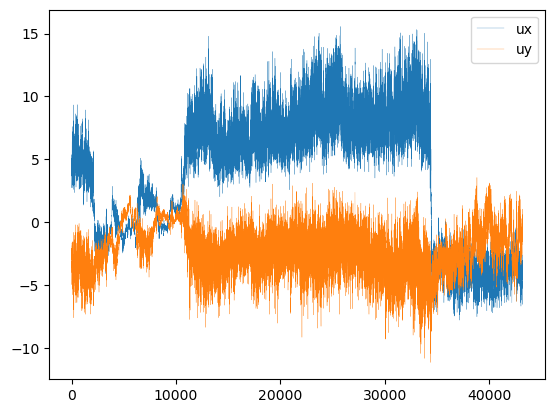

In [31]:
files = list(Path("/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/WyACT/wrtbi/L0c_ingested/Fast").glob("*.feather"))

dfs = []
for f in files:
    tmp = pd.read_feather(f, columns=["ux", "uy"]).astype(np.float32).iloc[::20]
    dfs.append(tmp)
df = pd.concat(dfs, ignore_index=True)
df = df.iloc[:86400//2]
df.plot(lw=0.2)

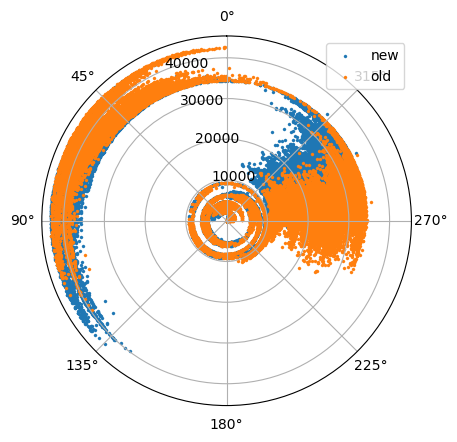

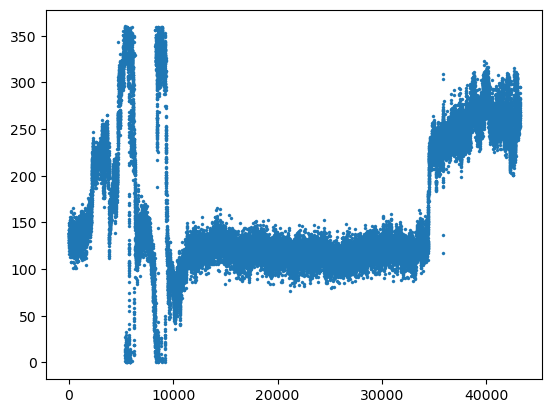

In [162]:
def compute_wd(ux, uy, offset):
    return (offset - np.arctan2(uy, ux)*180/np.pi + 1080) % 360
def compute_wd_old(ux, uy, offset):
    return (-np.arctan2(-uy, -ux)*180/np.pi - offset + 1080) % 360
# polar coordinates
# set the orientation so that 0 is up
fig, ax = plt.subplots(subplot_kw={"projection": "polar", "theta_offset": np.pi / 2})
ax.scatter(compute_wd(df["ux"], df["uy"], 280)*np.pi/180, np.arange(df["ux"].size), lw=0.2, s=5, label="new")
ax.scatter(compute_wd_old(df["ux"], df["uy"], 280)*np.pi/180, np.arange(df["ux"].size), lw=0.2, s=5, label="old")
ax.legend()
fig, ax = plt.subplots()
ax.scatter(np.arange(df["ux"].size), (280 - np.arctan2(-df["uy"], -df["ux"])*180/np.pi) % 360, lw=0.2, s=5)

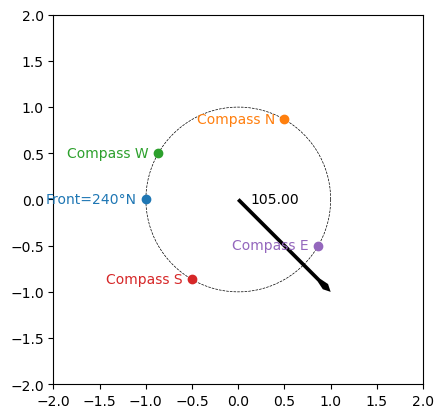

In [163]:
fig, ax = plt.subplots()

u = 1
v = -1
N0 = 240


theta_csat = np.arctan(v/u)*180/np.pi
theta_N0 = 180 - theta_csat
wd = theta_N0 + N0

wd = (N0 - np.atan2(-v, -u)*180/np.pi) % 360.0

# plot a circle
ax.plot(np.cos(np.linspace(0, 2*np.pi, 100)), np.sin(np.linspace(0, 2*np.pi, 100)), "k--", lw=0.5)
ax.quiver(0, 0, u, v, angles="xy", scale_units="xy", scale=1, headwidth=2, headlength=2, width=0.01)
ax.text(u/5+0.2, v/5+0.2, f"{wd:.2f}", va="center", ha="center", color="k")

ax.plot(-1, 0, 'o')
ax.text(-1.1, 0, f"Front={N0}°N", va="center", ha="right", color="C0")

ax.plot(np.cos(np.radians(N0+180)), np.sin(np.radians(N0+180)), 'o')
ax.text(np.cos(np.radians(N0+180))-0.1, np.sin(np.radians(N0+180)), "Compass N", va="center", ha="right", color="C1")
ax.plot(np.cos(np.radians(N0+180+90)), np.sin(np.radians(N0+180+90)), 'o')
ax.text(np.cos(np.radians(N0+180+90))-0.1, np.sin(np.radians(N0+180+90)), "Compass W", va="center", ha="right", color="C2")
ax.plot(np.cos(np.radians(N0+180+180)), np.sin(np.radians(N0+180+180)), 'o')
ax.text(np.cos(np.radians(N0+180+180))-0.1, np.sin(np.radians(N0+180+180)), "Compass S", va="center", ha="right", color="C3")
ax.plot(np.cos(np.radians(N0+180+270)), np.sin(np.radians(N0+180+270)), 'o')
ax.text(np.cos(np.radians(N0+180+270))-0.1, np.sin(np.radians(N0+180+270)), "Compass E", va="center", ha="right", color="C4")   

ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_aspect("equal")

<Axes: >

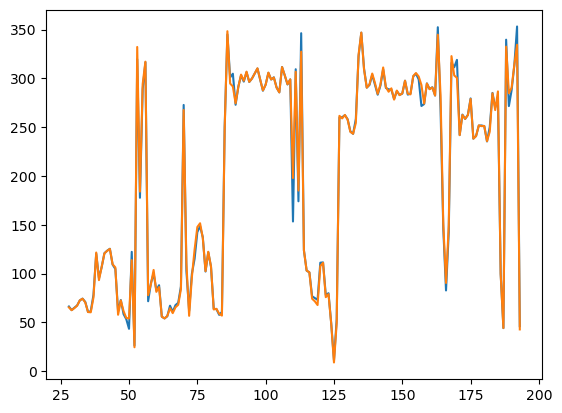

In [164]:
fnet = pd.read_csv("/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/WyACT/wrtbi/L2_eddypro_outputs/eddypro_test_fluxnet_2026-06-08T113021_adv.csv.tmp copy", na_values=-9999)
# fnet["V"]
# fnet["U"]
fnet["WD"].plot()
# fnet["WD_0_0_1"].plot()

# fnet["U_UNROT"].plot()
# fnet["V_UNROT"].plot()
((compute_wd(fnet["U_UNROT"], fnet["V_UNROT"], 280))%360).plot()
# compute_wd_old(fnet["U_UNROT"], fnet["V_UNROT"], 280).plot()